# 03 - Gold Layer (BI-ready KPIs)

**Fabric analogue:** A Warehouse or Semantic Model over Lakehouse silver tables,
surfaced via Power BI Direct Lake.

In [1]:
import polars as pl
from deltalake import write_deltalake, DeltaTable
from pathlib import Path
import shutil
import matplotlib.pyplot as plt

SILVER = Path('../data/silver')
GOLD = Path('../data/gold')
GOLD.mkdir(parents=True, exist_ok=True)

def read_delta(path: Path) -> pl.DataFrame:
    return pl.from_arrow(DeltaTable(str(path)).to_pyarrow_table())

def write_gold(df: pl.DataFrame, name: str):
    target = GOLD / name
    if target.exists():
        shutil.rmtree(target)
    write_deltalake(str(target), df.to_arrow(), mode='overwrite')
    return df.height

sales = read_delta(SILVER/'silver_fact_sales')
product = read_delta(SILVER/'silver_dim_product')
customer = read_delta(SILVER/'silver_dim_customer_scd2').filter(pl.col('is_current'))
print('sales:', sales.height, 'products:', product.height, 'customers (current):', customer.height)

sales: 400 products: 30 customers (current): 80


## Star-schema fact: fact_sales_enriched

In [2]:
fact = (
    sales
    .join(product.select(['product_sku','product_name','category','list_price']),
          on='product_sku', how='left')
    .join(customer.select(['customer_id','city','loyalty_tier']),
          on='customer_id', how='left')
)
write_gold(fact, 'gold_fact_sales')
fact.head(5)

sale_id,customer_id,store_id,product_sku,sale_ts,quantity,unit_price,payment_method,gross_amount,sale_date,product_name,category,list_price,city,loyalty_tier
i64,i64,str,str,datetime[μs],i64,f64,str,f64,date,str,str,f64,str,str
20,23,"""S02""","""SKU-008""",2025-01-16 02:33:00,2,7.34,"""card""",14.68,2025-01-16,"""Product 8""","""Home""",30.7,"""Montreal""","""platinum"""
278,24,"""S01""","""SKU-014""",2025-01-19 10:51:00,1,183.24,"""card""",183.24,2025-01-19,"""Product 14""","""Sports""",31.15,"""Montreal""","""gold"""
11,78,"""S01""","""SKU-004""",2025-02-22 10:01:00,4,37.16,"""wallet""",148.64,2025-02-22,"""Product 4""","""Home""",132.06,"""Montreal""","""gold"""
286,61,"""S01""","""SKU-009""",2025-01-24 11:28:00,2,92.89,"""cash""",185.78,2025-01-24,"""Product 9""","""Electronics""",113.83,"""Toronto""","""bronze"""
65,78,"""S02""","""SKU-003""",2025-01-16 05:52:00,3,173.23,"""card""",519.69,2025-01-16,"""Product 3""","""Food""",153.84,"""Montreal""","""gold"""


## KPI 1 - Daily revenue trend

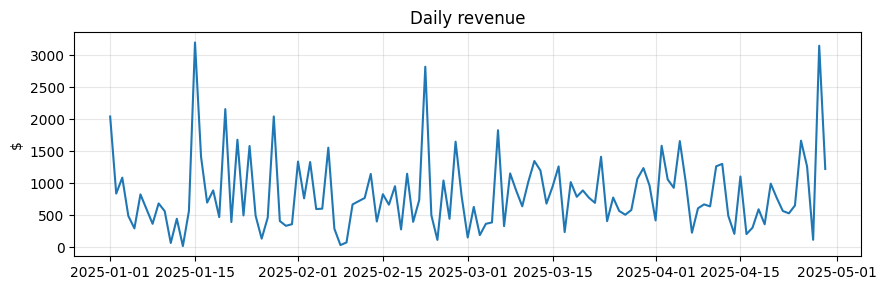

In [3]:
daily = (fact.group_by('sale_date')
              .agg([pl.col('gross_amount').sum().alias('revenue'),
                    pl.col('sale_id').n_unique().alias('orders')])
              .sort('sale_date'))
write_gold(daily, 'gold_kpi_daily_revenue')

fig, ax = plt.subplots(figsize=(9,3))
ax.plot(daily['sale_date'].to_list(), daily['revenue'].to_list())
ax.set_title('Daily revenue'); ax.set_ylabel('$'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## KPI 2 - Top products by revenue

In [4]:
top = (fact.group_by(['product_sku','product_name','category'])
            .agg(pl.col('gross_amount').sum().round(2).alias('revenue'))
            .sort('revenue', descending=True)
            .head(10))
write_gold(top, 'gold_kpi_top_products')
top

product_sku,product_name,category,revenue
str,str,str,f64
"""SKU-013""","""Product 13""","""Electronics""",6155.88
"""SKU-022""","""Product 22""","""Apparel""",5375.76
"""SKU-027""","""Product 27""","""Electronics""",4809.1
"""SKU-030""","""Product 30""","""Home""",4577.82
"""SKU-003""","""Product 3""","""Food""",4423.01
"""SKU-009""","""Product 9""","""Electronics""",4417.64
"""SKU-002""","""Product 2""","""Home""",4202.2
"""SKU-029""","""Product 29""","""Food""",3976.08
"""SKU-012""","""Product 12""","""Apparel""",3963.21


## KPI 3 - Revenue by loyalty tier (uses SCD2 current version)

In [5]:
tier = (fact.group_by('loyalty_tier')
             .agg([pl.col('gross_amount').sum().round(2).alias('revenue'),
                   pl.col('customer_id').n_unique().alias('customers')])
             .sort('revenue', descending=True))
write_gold(tier, 'gold_kpi_loyalty_tier_revenue')
tier

loyalty_tier,revenue,customers
str,f64,u32
"""bronze""",30258.52,22
"""gold""",27541.95,25
"""silver""",22436.2,18
"""platinum""",17584.65,14


## Gold artefacts

All four tables below are Delta-format and can be picked up directly by a
Fabric Lakehouse, Power BI (Direct Lake), Databricks, or any Arrow/Delta
consumer.

In [6]:
for p in sorted(GOLD.iterdir()):
    print(p.name)

gold_fact_sales
gold_kpi_daily_revenue
gold_kpi_loyalty_tier_revenue
gold_kpi_top_products
